In [4]:
import duckdb
from functions.evaluation import evaluate
from networks.cnn_batchnorm import CNNModel
from networks.cnn_network import build_dataloaders


con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()



train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']

drop_indices = train_rows[train_rows['label'] == 0].sample(frac=0.7).index


train_rows = train_rows.drop(drop_indices)
train_rows = train_rows[train_rows['label'].isin([0,1])]
val_rows = val_rows[val_rows['label'].isin([0,1])]

print(f"Antal utan m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")

CNN = CNNModel()
CNN.reset_weights()
cnn_train_dl, cnn_val_dl, _ = build_dataloaders(train_rows, val_rows, val_rows)
CNN.retrain(cnn_train_dl,cnn_val_dl,patience=15)

Antal utan m-komponent i träningsdatan: 17903
Antal med m-komponent i träningsdatan: 2553
  -> ny bästa modell sparad till ../models/convolution_model_batch_norm.pth
Epoch   0 | train: 0.5872 | val: 0.3600 | acc: 96.71% | AUC: 0.848  | LR: 0.001
  -> ny bästa modell sparad till ../models/convolution_model_batch_norm.pth
Epoch   1 | train: 0.4109 | val: 0.2795 | acc: 95.28% | AUC: 0.941  | LR: 0.001
  -> ny bästa modell sparad till ../models/convolution_model_batch_norm.pth
Epoch   2 | train: 0.3307 | val: 0.2118 | acc: 97.08% | AUC: 0.953  | LR: 0.001
Epoch   3 | train: 0.2954 | val: 0.3973 | acc: 97.29% | AUC: 0.933  | LR: 0.001
Epoch   4 | train: 0.2711 | val: 0.1962 | acc: 97.23% | AUC: 0.939  | LR: 0.001
  -> ny bästa modell sparad till ../models/convolution_model_batch_norm.pth
Epoch   5 | train: 0.2388 | val: 0.2470 | acc: 98.08% | AUC: 0.963  | LR: 0.001
Epoch   6 | train: 0.2118 | val: 0.1521 | acc: 97.32% | AUC: 0.962  | LR: 0.001
  -> ny bästa modell sparad till ../models/con

In [6]:
con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()


k_fold_rows = df[df['set'].isin(['train','val']) ].copy()
k_fold_rows = k_fold_rows[k_fold_rows['label'].isin([0,1])]
drop_indices = k_fold_rows[k_fold_rows['label'] == 0].sample(frac=0.7).index
k_fold_rows = k_fold_rows.drop(drop_indices)
print(f"Totalt antal utan m-komponent i K-fold poolen: {len(k_fold_rows[k_fold_rows['label'] == 0])}")
print(f"Totalt antal med m-komponent i K-fold poolen: {len(k_fold_rows[k_fold_rows['label'] == 1])}")

test_rows  = df[df['set'] == 'test']


CNN = CNNModel()
CNN.retrain_with_k_fold(k_fold_rows)

Totalt antal utan m-komponent i K-fold poolen: 18848
Totalt antal med m-komponent i K-fold poolen: 2692
--- Startar 10-Fold Cross Validation ---

 FOLD 1/10
  -> ny bästa modell sparad till ../models/convolution_model_batch_norm_fold1.pth
Epoch   0 | train: 0.5968 | val: 0.5759 | acc: 90.90% | AUC: 0.828  | LR: 0.001
  -> ny bästa modell sparad till ../models/convolution_model_batch_norm_fold1.pth
Epoch   1 | train: 0.4144 | val: 0.4736 | acc: 93.13% | AUC: 0.908  | LR: 0.001
  -> ny bästa modell sparad till ../models/convolution_model_batch_norm_fold1.pth
Epoch   2 | train: 0.3398 | val: 0.5042 | acc: 93.36% | AUC: 0.930  | LR: 0.001
  -> ny bästa modell sparad till ../models/convolution_model_batch_norm_fold1.pth
Epoch   3 | train: 0.2950 | val: 0.3175 | acc: 86.11% | AUC: 0.958  | LR: 0.001
  -> ny bästa modell sparad till ../models/convolution_model_batch_norm_fold1.pth
Epoch   4 | train: 0.2503 | val: 0.3721 | acc: 77.33% | AUC: 0.962  | LR: 0.001
  -> ny bästa modell sparad till 

,fold,train_loss,val_loss,val_accuracy,val_auc,val_spec,val_sens,tn,fp,fn,tp
0,1,0.074244,0.199960,96.702276,0.987097,0.978757,0.885185,1843,40,31,239
1,2,0.117285,0.123804,97.490706,0.989607,0.982997,0.918519,1850,32,22,248
2,3,0.099303,0.170430,95.448212,0.979434,0.960722,0.910781,1810,74,24,245
3,4,0.122340,0.204839,92.936803,0.980246,0.927244,0.944238,1746,137,15,254
4,5,0.107048,0.155859,94.472829,0.984603,0.946921,0.929368,1784,100,19,250
5,6,0.138475,0.130529,95.534884,0.986446,0.958533,0.933086,1803,78,18,251
6,7,0.154586,0.160843,96.193129,0.982497,0.971883,0.892193,1832,53,29,240
7,8,0.086614,0.184585,94.707521,0.980679,0.949072,0.933086,1789,96,18,251
8,9,0.091553,0.226726,94.656134,0.975472,0.950611,0.918216,1790,93,22,247
9,10,0.272150,0.305815,81.607060,0.987604,0.791401,0.988848,1491,393,3,266


              precision    recall  f1-score   support

     Negativ       0.99      0.98      0.99      7146
     Positiv       0.79      0.92      0.85       586

    accuracy                           0.98      7732
   macro avg       0.89      0.95      0.92      7732
weighted avg       0.98      0.98      0.98      7732

[[7004  142]
 [  44  542]]
AUC: 0.9883294695044078
Accuracy:  97.59%
FN-rate:   7.51%  (farliga missade fall)
FP-rate:   1.99%  (onödiga larm)
Sensitivitet:   92.49%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   98.01%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
AUC: 0.9883


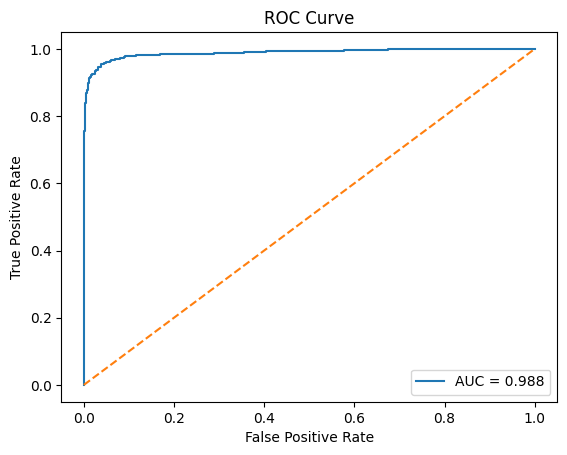

In [ ]:
test_rows = test_rows[test_rows['label'].isin([0,1])]
result = CNN.predict(test_rows)
_ = evaluate(result,threshold=0.5,proportion=70)